# Gold/USD — Exploratory Data Analysis — Last Two Years (2025-2026)

**Ironhack Final Project 2 — ML on Cloud**

Same analysis as `01_eda.ipynb`, run over a different observation window. Generated
from the same code, so any difference in the results comes from the data, not from
the method.

Observation window: **2y**.

**Why look at a shorter window at all.** The ten-year analysis found a regime
change: 2026 runs at roughly twice the volatility of the 2016-2024 average, and 21
of 29 features differ significantly between the training period and the holdout.
That raises a concrete question — is a model trained on ten years learning from a
market that no longer exists?


In [1]:
import sys, warnings
from pathlib import Path

warnings.filterwarnings("ignore")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.titlesize"] = 12

pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda v: f"{v:,.5f}")


In [2]:
# --- window configuration for this notebook -------------------------------
FETCH_PERIOD = "2y"
WINDOW_DAYS  = None     # None = use everything fetched
HOLDOUT_DAYS = 42

print(f"fetch period : {FETCH_PERIOD}")
print(f"analysis     : {'last ' + str(WINDOW_DAYS) + ' trading days' if WINDOW_DAYS else 'full fetched period'}")


fetch period : 2y
analysis     : full fetched period


## 1. Loading the data

Identical set of instruments as in the ten-year notebook: gold as the target, plus
dollar index, oil, S&P 500 and VIX as explanatory markets.


In [3]:
from src.data.fetch import fetch_all, TICKERS

frames = fetch_all(period=FETCH_PERIOD)

overview = pd.DataFrame({
    name: {"ticker": TICKERS[name], "rows": len(df),
           "from": df.index[0].date(), "to": df.index[-1].date()}
    for name, df in frames.items()
}).T
overview


,ticker,rows,from,to
gold,GC=F,504,2024-09-25,2026-09-25
dxy,DX-Y.NYB,503,2024-09-25,2026-09-25
oil,CL=F,504,2024-09-25,2026-09-25
sp500,^GSPC,500,2024-09-25,2026-09-24
vix,^VIX,503,2024-09-25,2026-09-25


In [4]:
from src.features.pipeline import align_panel

full_panel = align_panel(frames)

# The analysis window. Features were computed on the full fetched history,
# so rolling windows are complete even at the start of the window.
panel = full_panel.iloc[-WINDOW_DAYS:] if WINDOW_DAYS else full_panel

print(f"full fetched   : {len(full_panel)} rows   {full_panel.index[0].date()} to {full_panel.index[-1].date()}")
print(f"analysis window: {len(panel)} rows   {panel.index[0].date()} to {panel.index[-1].date()}")


full fetched   : 504 rows   2024-09-25 to 2026-09-25
analysis window: 504 rows   2024-09-25 to 2026-09-25


## 2. Data quality


In [5]:
gold_days = set(frames["gold"].index)
for name in ["dxy", "oil", "sp500", "vix"]:
    missing = len(gold_days - set(frames[name].index))
    print(f"{name:6s}: {missing:4d} gold trading days without an own observation "
          f"({missing / len(gold_days):.1%})")

print()
print("NaNs after forward-fill:")
print(panel.isna().sum().to_string())


dxy   :    2 gold trading days without an own observation (0.4%)
oil   :    0 gold trading days without an own observation (0.0%)
sp500 :    4 gold trading days without an own observation (0.8%)
vix   :    3 gold trading days without an own observation (0.6%)

NaNs after forward-fill:
gold_close     0
gold_high      0
gold_low       0
gold_volume    0
dxy_close      0
oil_close      0
sp500_close    0
vix_close      0


## 3. The price level


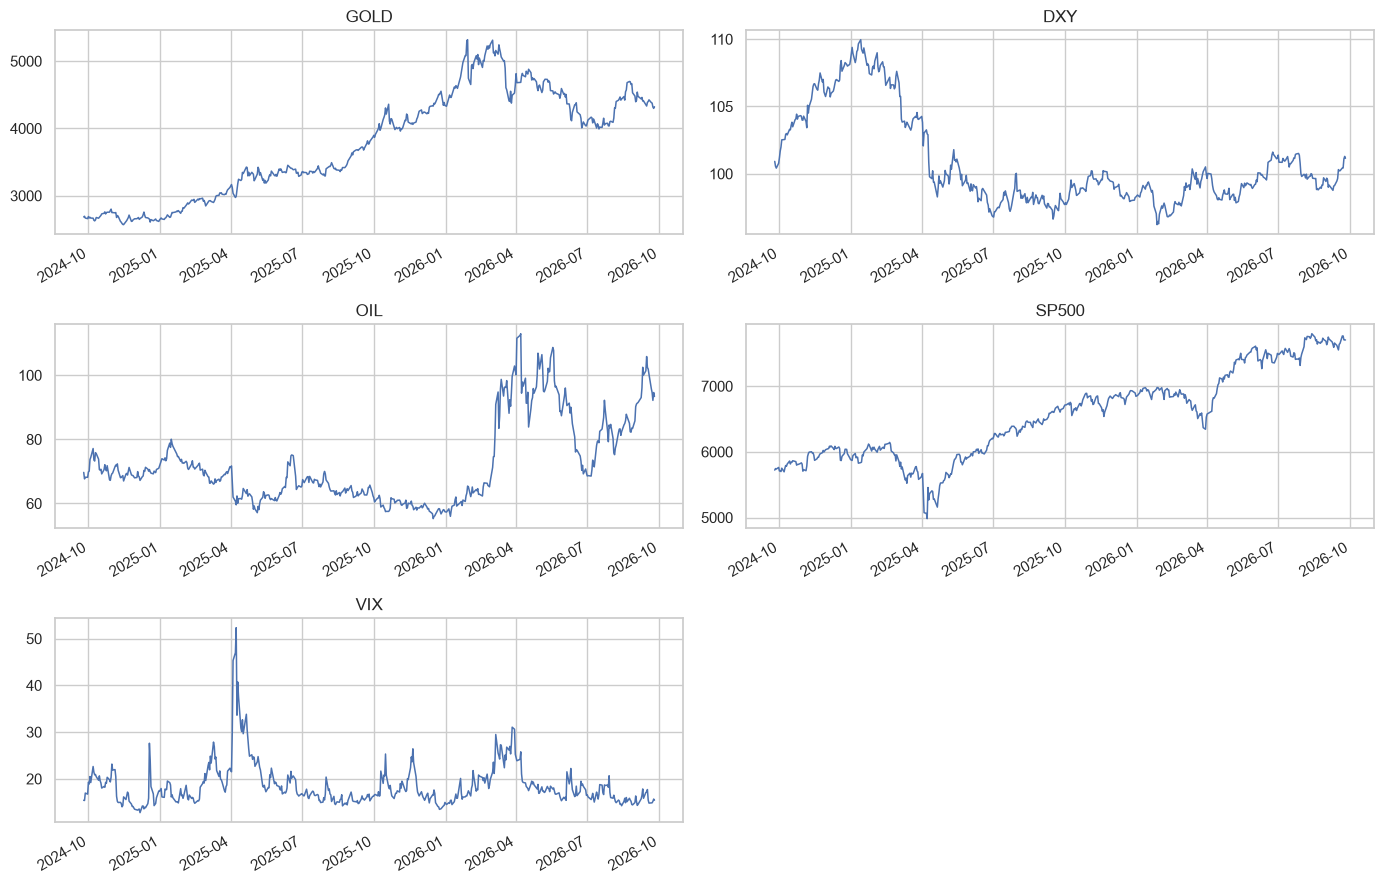

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(14, 9))
for ax, name in zip(axes.flat, ["gold", "dxy", "oil", "sp500", "vix"]):
    col = f"{name}_close"
    if col in panel:
        panel[col].plot(ax=ax, linewidth=1.1)
        ax.set_title(name.upper())
        ax.set_xlabel("")
axes.flat[-1].axis("off")
plt.tight_layout()
plt.show()


In [7]:
gold_period = panel["gold_close"]
print(f"start  : {gold_period.iloc[0]:,.1f}")
print(f"end    : {gold_period.iloc[-1]:,.1f}")
print(f"change : {(gold_period.iloc[-1] / gold_period.iloc[0] - 1):+.2%}")
print(f"min/max: {gold_period.min():,.1f} / {gold_period.max():,.1f}")


start  : 2,684.7
end    : 4,322.0
change : +60.99%
min/max: 2,570.1 / 5,318.4


## 4. Stationarity

**ADF** — null: unit root (non-stationary). `p < 0.05` → stationary.
**KPSS** — null: stationary. `p < 0.05` → non-stationary.


In [8]:
price = panel["gold_close"].dropna()
returns = price.pct_change().dropna()
abs_returns = returns.abs()

def safe_tests(series, name):
    """Both tests, degrading gracefully when the sample is too small."""
    row = {"series": name, "n": len(series)}
    try:
        stat, p, *_ = adfuller(series, autolag="AIC")
        row |= {"ADF_stat": stat, "ADF_p": p,
                "ADF_verdict": "stationary" if p < 0.05 else "NON-stationary"}
    except Exception as exc:
        row |= {"ADF_stat": np.nan, "ADF_p": np.nan, "ADF_verdict": f"n/a ({type(exc).__name__})"}
    try:
        stat, p, *_ = kpss(series, regression="c", nlags="auto")
        row |= {"KPSS_stat": stat, "KPSS_p": p,
                "KPSS_verdict": "NON-stationary" if p < 0.05 else "stationary"}
    except Exception as exc:
        row |= {"KPSS_stat": np.nan, "KPSS_p": np.nan, "KPSS_verdict": f"n/a ({type(exc).__name__})"}
    return row

pd.DataFrame([
    safe_tests(price, "gold price level"),
    safe_tests(returns, "gold returns"),
    safe_tests(abs_returns, "absolute returns"),
]).set_index("series")


/var/folders/gn/zvx5kxqj5ng9ng0cg5f15yk80000gn/T/ipykernel_13300/2517348725.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  stat, p, *_ = kpss(series, regression="c", nlags="auto")
/var/folders/gn/zvx5kxqj5ng9ng0cg5f15yk80000gn/T/ipykernel_13300/2517348725.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  stat, p, *_ = kpss(series, regression="c", nlags="auto")
/var/folders/gn/zvx5kxqj5ng9ng0cg5f15yk80000gn/T/ipykernel_13300/2517348725.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  stat, p, *_ = kpss(series, regression="c", nlags="auto")


,n,ADF_stat,ADF_p,ADF_verdict,KPSS_stat,KPSS_p,KPSS_verdict
series,,,,,,,
gold price level,504,-1.31488,0.62234,NON-stationary,3.21026,0.01000,NON-stationary
gold returns,503,-23.00127,0.00000,stationary,0.14709,0.10000,stationary
absolute returns,503,-4.37113,0.00033,stationary,0.76389,0.01000,NON-stationary


## 5. Distribution of returns


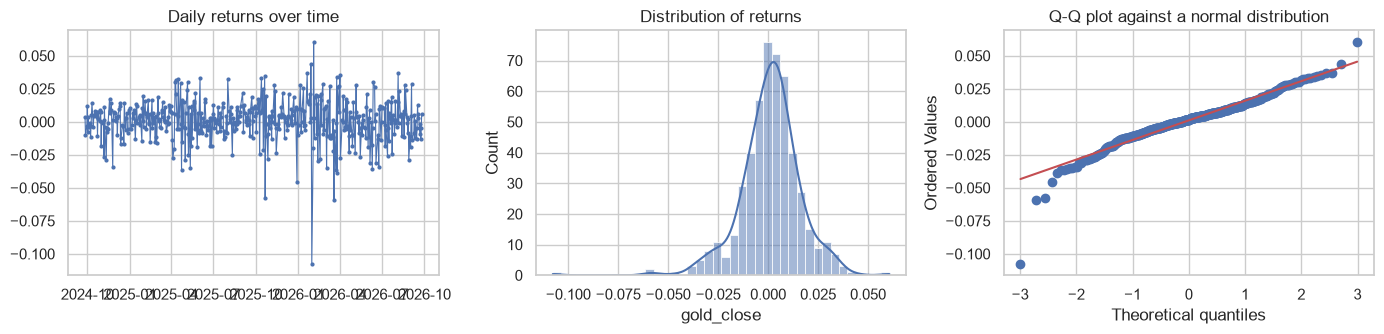

n          : 503
mean       : +0.001064   (+26.82% annualised)
std        : 0.015262    (24.23% annualised)
skew       : -0.9255
kurtosis   : +6.0570
share up   : 0.5547


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

axes[0].plot(returns.index, returns.values, linewidth=0.8, marker="o", markersize=2)
axes[0].set_title("Daily returns over time")

sns.histplot(returns, bins=min(40, max(8, len(returns) // 3)), kde=len(returns) > 30, ax=axes[1])
axes[1].set_title("Distribution of returns")

from scipy import stats
stats.probplot(returns, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q plot against a normal distribution")

plt.tight_layout()
plt.show()

print(f"n          : {len(returns)}")
print(f"mean       : {returns.mean():+.6f}   ({returns.mean() * 252:+.2%} annualised)")
print(f"std        : {returns.std():.6f}    ({returns.std() * np.sqrt(252):.2%} annualised)")
print(f"skew       : {returns.skew():+.4f}")
print(f"kurtosis   : {returns.kurtosis():+.4f}")
print(f"share up   : {(returns > 0).mean():.4f}")


## 6. Autocorrelation — is there anything to predict?


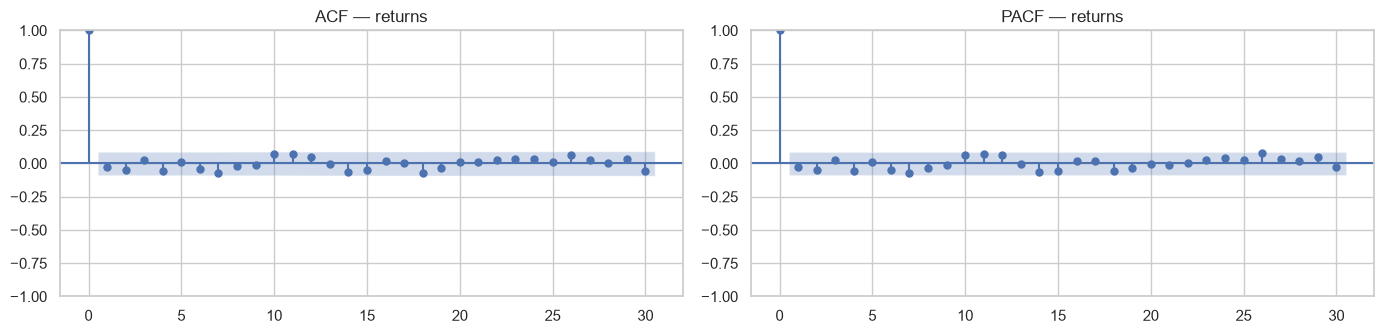

95% white-noise band: +/- 0.0874   (n = 503)


,ACF,PACF,significant
lag,,,
1,-0.02830,-0.02830,-
2,-0.05110,-0.05210,-
3,0.02590,0.02320,-
4,-0.05390,-0.05580,-
5,0.01280,0.01240,-
6,-0.04210,-0.04870,-
7,-0.07050,-0.07060,-
8,-0.02000,-0.03340,-
9,-0.00840,-0.01480,-


In [10]:
max_lags = min(30, max(1, len(returns) // 3))
ci = 1.96 / np.sqrt(len(returns))

fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))
plot_acf(returns, lags=max_lags, ax=axes[0], title="ACF — returns")
plot_pacf(returns, lags=min(max_lags, len(returns) // 2 - 1), ax=axes[1],
          title="PACF — returns", method="ywm")
plt.tight_layout()
plt.show()

n_show = min(10, max_lags)
a = acf(returns, nlags=n_show, fft=True)
p_ = pacf(returns, nlags=min(n_show, len(returns) // 2 - 1))
tbl = pd.DataFrame({
    "ACF": a[1:n_show + 1].round(4),
    "PACF": np.pad(p_[1:], (0, max(0, n_show - len(p_) + 1)),
                   constant_values=np.nan)[:n_show].round(4),
}, index=pd.RangeIndex(1, n_show + 1, name="lag"))
tbl["significant"] = ["yes" if abs(v) > ci else "-" for v in tbl["ACF"]]
print(f"95% white-noise band: +/- {ci:.4f}   (n = {len(returns)})")
tbl


In [11]:
lags = [l for l in (5, 10, 20) if l < len(returns) // 2]
if lags:
    print("Ljung-Box, joint test across lags:")
    print(acorr_ljungbox(returns, lags=lags, return_df=True).round(6))
else:
    print(f"Sample too small for a Ljung-Box test (n = {len(returns)}).")


Ljung-Box, joint test across lags:
    lb_stat  lb_pvalue
5   3.63237    0.60346
10  9.94368    0.44545
20 21.21346    0.38467


## 7. Volatility clustering


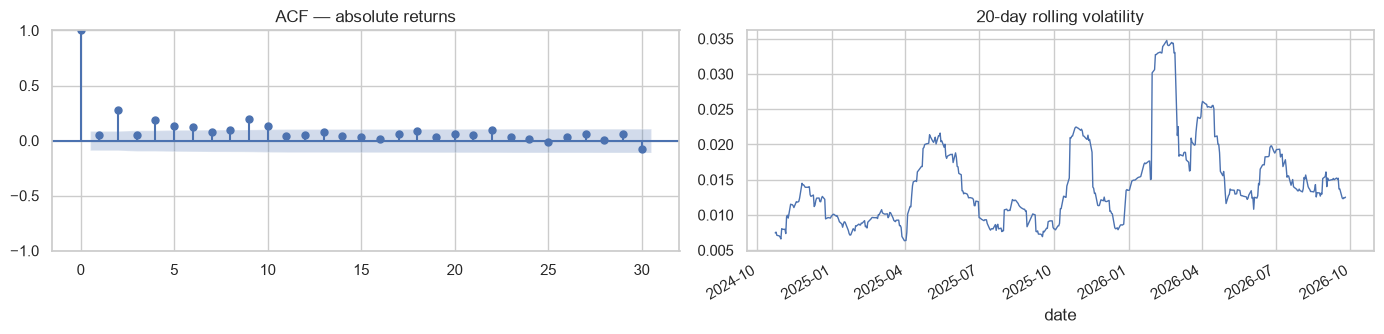

,ACF returns,ACF abs returns,abs significant
lag,,,
1,-0.02830,0.05190,-
2,-0.05110,0.27370,yes
3,0.02590,0.05170,-
4,-0.05390,0.18860,yes
5,0.01280,0.12790,yes
6,-0.04210,0.12600,yes
7,-0.07050,0.07660,-
8,-0.02000,0.09930,yes
9,-0.00840,0.19440,yes


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))
plot_acf(abs_returns, lags=max_lags, ax=axes[0], title="ACF — absolute returns")

window = 20 if len(full_panel) > 60 else 5
full_panel["gold_close"].pct_change().rolling(window).std().tail(
    len(panel) * 3 if WINDOW_DAYS else len(full_panel)
).plot(ax=axes[1], linewidth=1.0, title=f"{window}-day rolling volatility")
plt.tight_layout()
plt.show()

aa = acf(abs_returns, nlags=n_show, fft=True)
pd.DataFrame({
    "ACF returns": a[1:n_show + 1].round(4),
    "ACF abs returns": aa[1:n_show + 1].round(4),
    "abs significant": ["yes" if abs(v) > ci else "-" for v in aa[1:n_show + 1]],
}, index=pd.RangeIndex(1, n_show + 1, name="lag"))


In [13]:
if lags:
    lb_ret = acorr_ljungbox(returns, lags=[max(lags)], return_df=True)
    lb_abs = acorr_ljungbox(abs_returns, lags=[max(lags)], return_df=True)
    print(f"Ljung-Box across lags 1-{max(lags)}")
    print(f"  returns          stat = {lb_ret['lb_stat'].iloc[0]:8.2f}   p = {lb_ret['lb_pvalue'].iloc[0]:.6f}")
    print(f"  absolute returns stat = {lb_abs['lb_stat'].iloc[0]:8.2f}   p = {lb_abs['lb_pvalue'].iloc[0]:.6f}")
else:
    print("Sample too small for a Ljung-Box test.")


Ljung-Box across lags 1-20
  returns          stat =    21.21   p = 0.384666
  absolute returns stat =   126.59   p = 0.000000


## 8. External markets


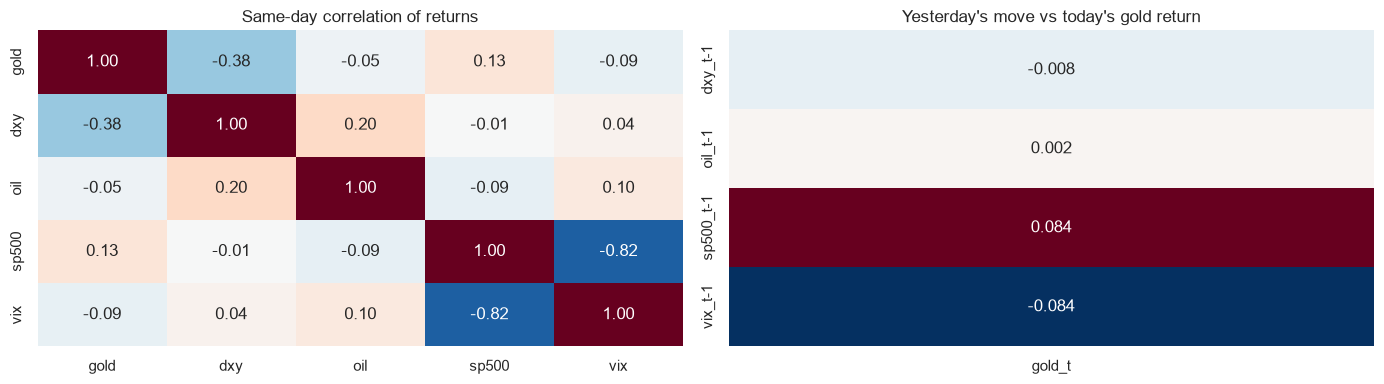

In [14]:
ret_panel = pd.DataFrame({
    name: panel[f"{name}_close"].pct_change()
    for name in ["gold", "dxy", "oil", "sp500", "vix"] if f"{name}_close" in panel
}).dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.heatmap(ret_panel.corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            ax=axes[0], cbar=False)
axes[0].set_title("Same-day correlation of returns")

lagged = pd.DataFrame({f"{c}_t-1": ret_panel[c].shift(1)
                       for c in ret_panel.columns if c != "gold"})
lagged["gold_t"] = ret_panel["gold"]
sns.heatmap(lagged.corr()[["gold_t"]].drop("gold_t"), annot=True, fmt=".3f",
            cmap="RdBu_r", center=0, ax=axes[1], cbar=False)
axes[1].set_title("Yesterday's move vs today's gold return")
plt.tight_layout()
plt.show()


## 9. Drift — has the most recent period moved away from what came before?

The last **42 trading days** are compared against everything
before them, using the same PSI and KS implementation that the production drift
Lambda uses.


In [15]:
from src.features.pipeline import feature_columns, make_training_frame
from src.monitoring.drift import compare

frame = make_training_frame(frames)          # built on the FULL fetched history
cols = feature_columns(frame)

reference_frame = frame.iloc[:-HOLDOUT_DAYS]
recent_frame = frame.iloc[-HOLDOUT_DAYS:]

n, m = len(reference_frame), len(recent_frame)
d_crit = 1.36 * np.sqrt((n + m) / (n * m))

print(f"Reference : {reference_frame.index[0].date()} to {reference_frame.index[-1].date()}  ({n} rows)")
print(f"Recent    : {recent_frame.index[0].date()} to {recent_frame.index[-1].date()}  ({m} rows)")
print(f"\nKS critical value at alpha = 0.05: D = {d_crit:.4f}")

drift = compare(reference_frame, recent_frame, cols)
print(f"Features above it: {(drift['ks_stat'] > d_crit).sum()} of {len(drift)}")
print(f"\nPSI verdicts:\n{drift['verdict'].value_counts().to_string()}")
drift.head(12)


Reference : 2024-10-23 to 2026-07-27  (441 rows)
Recent    : 2026-07-28 to 2026-09-24  (42 rows)

KS critical value at alpha = 0.05: D = 0.2196
Features above it: 12 of 29

PSI verdicts:
verdict
significant    22
moderate        6
stable          1


,feature,psi,verdict,ks_stat,ks_p,ks_significant
0,month,10.81530,significant,0.55780,0.00000,True
1,gold_vol20,9.08320,significant,0.46030,0.00000,True
2,dxy_vol10,6.67030,significant,0.55900,0.00000,True
3,gold_vol10,5.57310,significant,0.37760,0.00000,True
4,vix_vol10,4.09800,significant,0.28460,0.00310,True
5,oil_vol10,3.70480,significant,0.40820,0.00000,True
6,gold_vol5,2.73160,significant,0.18030,0.14710,False
7,gold_range,2.56030,significant,0.31070,0.00090,True
8,gold_ma_ratio20,2.01690,significant,0.30610,0.00110,True
9,sp500_vol10,1.58540,significant,0.24380,0.01740,True


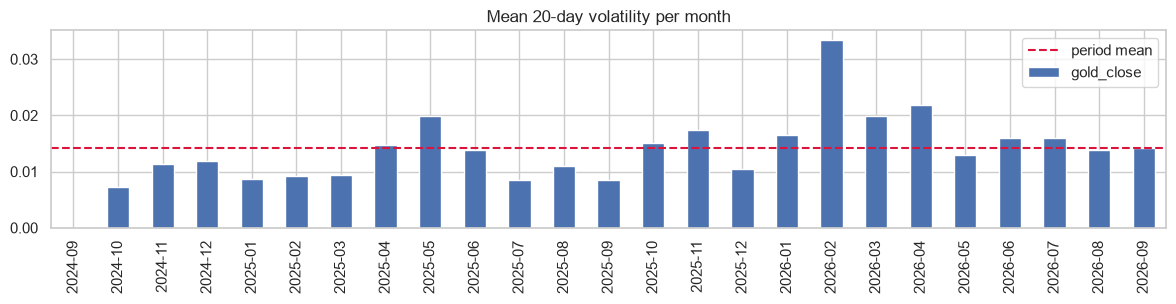

2024-09       NaN
2024-10   0.00725
2024-11   0.01131
2024-12   0.01184
2025-01   0.00866
2025-02   0.00915
2025-03   0.00933
2025-04   0.01474
2025-05   0.01989
2025-06   0.01385
2025-07   0.00857
2025-08   0.01105
2025-09   0.00843
2025-10   0.01510
2025-11   0.01746
2025-12   0.01042
2026-01   0.01649
2026-02   0.03343
2026-03   0.01997
2026-04   0.02180
2026-05   0.01293
2026-06   0.01596
2026-07   0.01593
2026-08   0.01384
2026-09   0.01419
Name: gold_close, dtype: float64

In [16]:
vol = full_panel["gold_close"].pct_change().rolling(20).std()
by_month = vol.groupby([vol.index.year, vol.index.month]).mean()
by_month.index = [f"{y}-{m:02d}" for y, m in by_month.index]

ax = by_month.plot(kind="bar", figsize=(12, 3.2),
                   title="Mean 20-day volatility per month")
ax.axhline(by_month.mean(), color="crimson", linestyle="--", label="period mean")
ax.legend()
plt.tight_layout()
plt.show()
by_month.round(5)


## 10. Comparison against the ten-year analysis

Put the numbers from this notebook next to those from `01_eda.ipynb`. What differs
is the answer to the question that motivated this exercise: **is a shorter training
window the better basis for the model?**

Reference values from the ten-year notebook:

| Measure | Ten years (2016-2026) |
|---|---|
| Returns: significant ACF lags (of 10) | 2 |
| Ljung-Box returns, lags 1-10 | p = 0.023 |
| Absolute returns: significant ACF lags | 10 of 10 |
| Ljung-Box absolute returns | p < 0.000001 |
| Annualised volatility | 16.96% |
| Annualised mean return | +13.20% |
| Excess kurtosis | 7.56 |
| Skew | −0.57 |

Read the corresponding values above and note where they diverge. A materially
different volatility level or autocorrelation structure is direct evidence for
shortening the training window.
